# Data Visualization Project: Video Game Sales Analysis

### Course Project

**Notebook:** `Video_Game_Sales_Analysis.ipynb`

**Tools Used:** Python, Pandas, Plotly, Jupyter Notebook

**Dataset:** Video Game Sales Dataset

In [2]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

In [3]:
## Load the Dataset
df = pd.read_csv(r"C:\Users\Sakshit\Desktop\clg projects\SEM 2\Data Visualization\Project\Data-viz\Video_Games.csv")

# Dataset Overview

In [4]:
# Display the number of rows and columns
df.shape

# Display the first five rows
df.head()

# Display the last five rows
df.tail()

# Display all column names
df.columns

# Display dataset information
df.info()

# Display summary statistics for numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16928 entries, 0 to 16927
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            16928 non-null  int64  
 1   Name             16926 non-null  str    
 2   Platform         16928 non-null  str    
 3   Year_of_Release  16655 non-null  float64
 4   Genre            16926 non-null  str    
 5   Publisher        16873 non-null  str    
 6   NA_Sales         16928 non-null  float64
 7   EU_Sales         16928 non-null  float64
 8   JP_Sales         16928 non-null  float64
 9   Other_Sales      16928 non-null  float64
 10  Global_Sales     16928 non-null  float64
 11  Critic_Score     8260 non-null   float64
 12  Critic_Count     8260 non-null   float64
 13  User_Score       10159 non-null  str    
 14  User_Count       7718 non-null   float64
 15  Developer        10240 non-null  str    
 16  Rating           10092 non-null  str    
dtypes: float64(9), int64(1)

,index,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16928.000000,16655.00000,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,8260.000000,8260.000000,7718.000000
mean,8463.500000,2006.48532,0.266390,0.146850,0.078170,0.047861,0.539520,69.037893,26.428692,163.269629
std,4886.837014,5.88289,0.814326,0.504585,0.308756,0.186675,1.550545,13.943198,18.989929,562.786746
min,0.000000,1980.00000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,4231.750000,2003.00000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,8463.500000,2007.00000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,25.000000
75%,12695.250000,2010.00000,0.240000,0.110000,0.040000,0.040000,0.490000,79.000000,36.000000,82.000000
max,16927.000000,2020.00000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


# Preliminary Exploratory Data Analysis (EDA)

In [5]:
# Check for missing values
df.isnull().sum()

# Check for duplicate rows
df.duplicated().sum()

# Number of unique values in each column
df.nunique()

# Check data types again
df.dtypes

# Display summary statistics including categorical columns
df.describe(include="all")

# Check skewness of numerical columns
df.skew(numeric_only=True)

index               0.000000
Year_of_Release    -0.974192
NA_Sales           18.531848
EU_Sales           18.546630
JP_Sales           11.117583
Other_Sales        24.339496
Global_Sales       17.130208
Critic_Score       -0.614111
Critic_Count        1.149353
User_Count          8.937720
dtype: float64

# Data Cleaning

In [6]:
# Create a copy of the original dataset
games_df = df.copy()

games_df.head()

# Remove duplicate rows (if any)
games_df = games_df.drop_duplicates()

print("Dataset shape after removing duplicates:")
games_df.shape

# Missing values after removing duplicates
games_df.isnull().sum() 

games_df.columns

games_df.dtypes

Dataset shape after removing duplicates:


index                int64
Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score             str
User_Count         float64
Developer              str
Rating                 str
dtype: object

In [7]:
games_df.columns.tolist()

['index',
 'Name',
 'Platform',
 'Year_of_Release',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales',
 'Critic_Score',
 'Critic_Count',
 'User_Score',
 'User_Count',
 'Developer',
 'Rating']

# Removing Unnecessary Columns

In [8]:
# Remove the unnecessary index column
games_df.drop(columns=["index"], inplace=True)

games_df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


# Converting Data Types

In [9]:
games_df["User_Score"] = pd.to_numeric(
    games_df["User_Score"],
    errors="coerce"
) 

games_df.dtypes

Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer              str
Rating                 str
dtype: object

# Handling Missing Values

In [10]:
games_df = games_df.dropna(
    subset=[
        "Year_of_Release",
        "Genre",
        "Publisher",
        "Critic_Score",
        "User_Score",
        "Global_Sales"
    ]
)

games_df.isnull().sum()

Name                0
Platform            0
Year_of_Release     0
Genre               0
Publisher           0
NA_Sales            0
EU_Sales            0
JP_Sales            0
Other_Sales         0
Global_Sales        0
Critic_Score        0
Critic_Count        0
User_Score          0
User_Count          0
Developer           4
Rating             69
dtype: int64

# Feature Engineering

In [11]:
games_df["Total_Sales"] = (
    games_df["NA_Sales"] +
    games_df["EU_Sales"] +
    games_df["JP_Sales"] +
    games_df["Other_Sales"]
)

games_df["Decade"] = (
    games_df["Year_of_Release"] // 10
) * 10


CURRENT_YEAR = 2026

games_df["Game_Age"] = (
    CURRENT_YEAR -
    games_df["Year_of_Release"]
)

games_df[
    [
        "Year_of_Release",
        "Decade",
        "Game_Age",
        "Total_Sales"
    ]
].head()

,Year_of_Release,Decade,Game_Age,Total_Sales
0,2006.0,2000.0,20.0,82.54
2,2008.0,2000.0,18.0,35.52
3,2009.0,2000.0,17.0,32.77
6,2006.0,2000.0,20.0,29.80
7,2006.0,2000.0,20.0,28.91


# Final Dataset Validation

In [12]:
games_df.info()

<class 'pandas.DataFrame'>
Index: 7007 entries, 0 to 16926
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             7007 non-null   str    
 1   Platform         7007 non-null   str    
 2   Year_of_Release  7007 non-null   float64
 3   Genre            7007 non-null   str    
 4   Publisher        7007 non-null   str    
 5   NA_Sales         7007 non-null   float64
 6   EU_Sales         7007 non-null   float64
 7   JP_Sales         7007 non-null   float64
 8   Other_Sales      7007 non-null   float64
 9   Global_Sales     7007 non-null   float64
 10  Critic_Score     7007 non-null   float64
 11  Critic_Count     7007 non-null   float64
 12  User_Score       7007 non-null   float64
 13  User_Count       7007 non-null   float64
 14  Developer        7003 non-null   str    
 15  Rating           6938 non-null   str    
 16  Total_Sales      7007 non-null   float64
 17  Decade           7007 non-nul

In [13]:
games_df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Total_Sales,Decade,Game_Age
count,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000,7007.000000
mean,2007.484658,0.395075,0.237313,0.064525,0.082737,0.779822,70.313258,28.889539,7.184887,175.588697,0.779650,2003.066933,18.515342
std,4.237121,0.964055,0.684967,0.286302,0.267981,1.956307,13.863550,19.196590,1.439430,586.601044,1.956548,4.876312,4.237121
min,1985.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.500000,4.000000,0.010000,1980.000000,10.000000
25%,2004.000000,0.060000,0.020000,0.000000,0.010000,0.110000,62.000000,14.000000,6.500000,11.000000,0.110000,2000.000000,15.000000
50%,2007.000000,0.150000,0.060000,0.000000,0.020000,0.300000,72.000000,24.000000,7.500000,27.000000,0.300000,2000.000000,19.000000
75%,2011.000000,0.390000,0.210000,0.010000,0.070000,0.740000,81.000000,39.000000,8.200000,90.000000,0.740000,2010.000000,22.000000
max,2016.000000,41.360000,28.960000,6.500000,10.570000,82.530000,98.000000,113.000000,9.600000,10665.000000,82.540000,2010.000000,41.000000


In [14]:
games_df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Total_Sales,Decade,Game_Age
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E,82.54,2000.0,20.0
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,35.52,2000.0,18.0
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E,32.77,2000.0,17.0
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E,29.80,2000.0,20.0
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E,28.91,2000.0,20.0


# Analytical Questions

# Question 1: Which gaming platforms have generated the highest global sales?

In [15]:
platform_sales = (
    games_df
    .groupby("Platform", as_index=False)["Global_Sales"]
    .sum()
    .sort_values(by="Global_Sales", ascending=False)
)

platform_sales.head(10)

,Platform,Global_Sales
7,PS2,970.24
14,X360,869.82
8,PS3,806.08
12,Wii,684.06
2,DS,384.82
9,PS4,252.71
6,PS,225.42
15,XB,216.69
5,PC,192.79
10,PSP,189.79


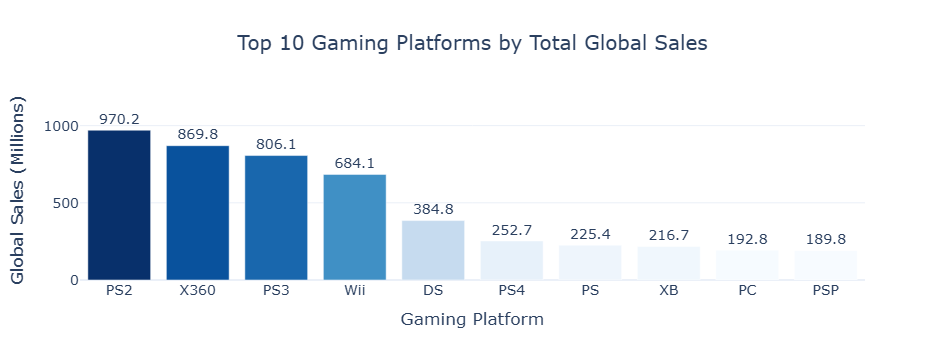

In [16]:
fig = px.bar(
    platform_sales.head(10),
    x="Platform",
    y="Global_Sales",
    color="Global_Sales",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Top 10 Gaming Platforms by Total Global Sales"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Gaming Platform",
    yaxis_title="Global Sales (Millions)",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

# Insight
    The visualization shows that only a few gaming platforms account for a significant share of global video game sales. Nintendo's Wii and DS, along with Sony's PlayStation 2, rank among the most successful platforms. This suggests that platform popularity and a strong library of games play a major role in driving commercial success.

# Question 2: Which game genres have generated the highest global sales?

In [17]:
genre_sales = (
    games_df
    .groupby("Genre", as_index=False)["Global_Sales"]
    .sum()
    .sort_values(by="Global_Sales", ascending=False)
)

genre_sales

,Genre,Global_Sales
0,Action,1225.23
10,Sports,848.64
8,Shooter,848.17
7,Role-Playing,514.88
6,Racing,497.58
3,Misc,434.78
4,Platform,389.28
2,Fighting,267.96
9,Simulation,206.11
1,Adventure,82.13


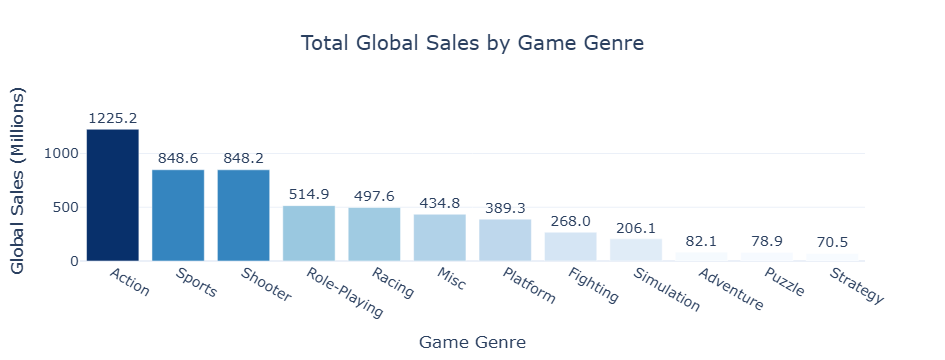

In [18]:
fig = px.bar(
    genre_sales,
    x="Genre",
    y="Global_Sales",
    color="Global_Sales",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Total Global Sales by Game Genre"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Game Genre",
    yaxis_title="Global Sales (Millions)",
    coloraxis_showscale=False,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

# Insight
    The visualization highlights the commercial performance of different video game genres. Action and Sports games are among the highest-selling genres, indicating broad appeal across gaming audiences. In contrast, genres such as Puzzle and Strategy contribute comparatively lower global sales, suggesting a more niche market.

# Question 3: How have global video game sales changed over time?

In [19]:
yearly_sales = (
    games_df
    .groupby("Year_of_Release", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Year_of_Release")
)

yearly_sales.head()

,Year_of_Release,Global_Sales
0,1985.0,0.03
1,1988.0,0.03
2,1992.0,0.03
3,1994.0,1.27
4,1996.0,20.35


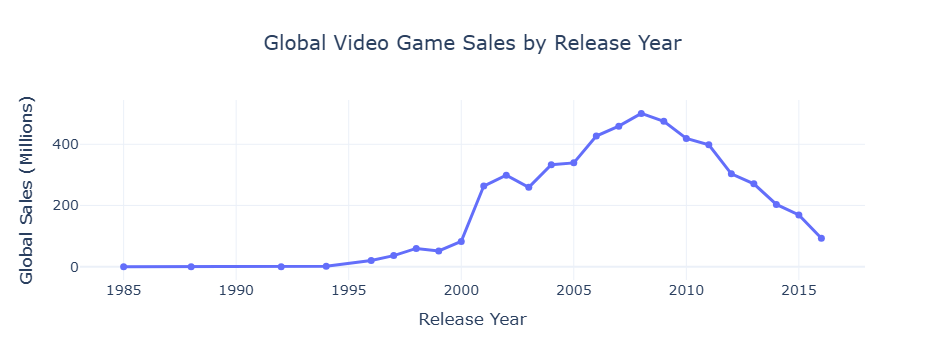

In [20]:
fig = px.line(
    yearly_sales,
    x="Year_of_Release",
    y="Global_Sales",
    markers=True,
    title="Global Video Game Sales by Release Year"
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=7)
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Release Year",
    yaxis_title="Global Sales (Millions)",
    font=dict(size=14)
)

fig.show()

# Insight
    The line chart reveals how global video game sales have changed over time. Sales increased steadily during the late 1990s and early 2000s, reached a peak during the late 2000s, and then gradually declined in subsequent years. This trend may reflect market saturation, the transition to digital distribution, and the relatively smaller number of recent games included in the dataset.

# Question 4: Is there a relationship between critic scores and global sales?

In [21]:
critic_sales = games_df[
    ["Critic_Score", "Global_Sales", "Genre", "Platform", "Name"]
].dropna()

critic_sales.head()

,Critic_Score,Global_Sales,Genre,Platform,Name
0,76.0,82.53,Sports,Wii,Wii Sports
2,82.0,35.52,Racing,Wii,Mario Kart Wii
3,80.0,32.77,Sports,Wii,Wii Sports Resort
6,89.0,29.80,Platform,DS,New Super Mario Bros.
7,58.0,28.92,Misc,Wii,Wii Play


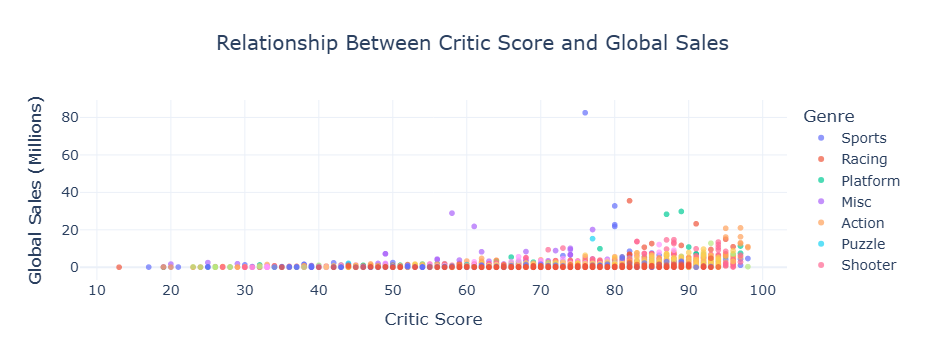

In [22]:
fig = px.scatter(
    critic_sales,
    x="Critic_Score",
    y="Global_Sales",
    color="Genre",
    hover_data=["Name", "Platform"],
    title="Relationship Between Critic Score and Global Sales",
    opacity=0.7
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Critic Score",
    yaxis_title="Global Sales (Millions)",
    font=dict(size=14),
    legend_title="Genre"
)

fig.show()

# Insight
    The scatter plot suggests a positive relationship between critic scores and global sales. Games with higher critic scores generally achieve stronger sales, although there are several exceptions. A few blockbuster titles generate exceptional sales despite receiving only average critic ratings, indicating that factors such as franchise popularity, marketing, and platform availability also influence commercial success.

# Question 5: Do user scores agree with critic scores?

In [23]:
score_comparison = games_df[
    ["User_Score", "Critic_Score", "Genre", "Name"]
].dropna()

score_comparison.head()

,User_Score,Critic_Score,Genre,Name
0,8.0,76.0,Sports,Wii Sports
2,8.3,82.0,Racing,Mario Kart Wii
3,8.0,80.0,Sports,Wii Sports Resort
6,8.5,89.0,Platform,New Super Mario Bros.
7,6.6,58.0,Misc,Wii Play


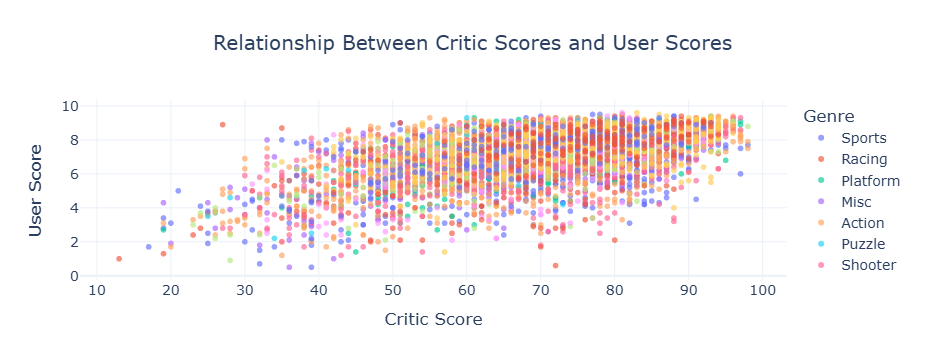

In [24]:
fig = px.scatter(
    score_comparison,
    x="Critic_Score",
    y="User_Score",
    color="Genre",
    hover_data=["Name"],
    opacity=0.65,
    title="Relationship Between Critic Scores and User Scores"
)

fig.update_traces(
    marker=dict(size=6)
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Critic Score",
    yaxis_title="User Score",
    font=dict(size=14),
    legend_title="Genre"
)

fig.show()

# Insight
    The scatter plot indicates a generally positive relationship between critic scores and user scores, suggesting that professional critics and players often have similar opinions about game quality. However, several games deviate from this pattern, indicating cases where user opinions differ substantially from critic reviews. These differences may result from player expectations, franchise popularity, or gameplay preferences.

# Question 6: Which publishers have generated the highest global sales?

In [26]:
publisher_sales = (
    games_df
    .groupby("Publisher", as_index=False)["Global_Sales"]
    .sum()
    .sort_values(by="Global_Sales", ascending=False)
    .head(10)
)

publisher_sales

,Publisher,Global_Sales
65,Electronic Arts,903.23
167,Nintendo,874.77
11,Activision,544.47
208,Sony Computer Entertainment,404.26
246,Ubisoft,358.07
232,Take-Two Interactive,353.27
150,Microsoft Game Studios,223.85
229,THQ,164.74
205,Sega,154.34
128,Konami Digital Entertainment,138.63


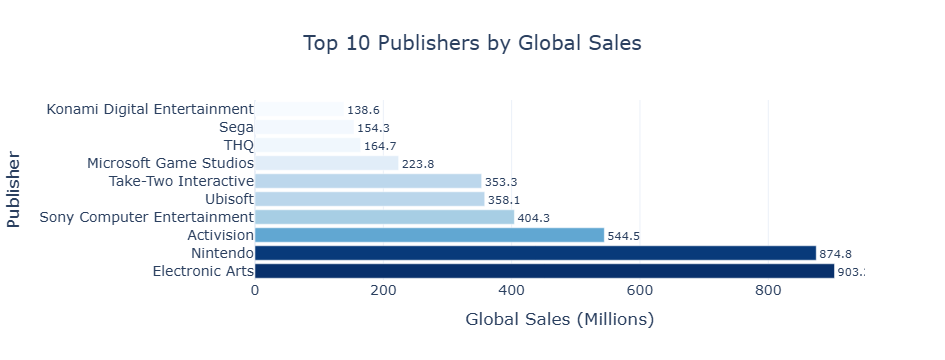

In [27]:
fig = px.bar(
    publisher_sales,
    x="Global_Sales",
    y="Publisher",
    orientation="h",
    color="Global_Sales",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Top 10 Publishers by Global Sales"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Global Sales (Millions)",
    yaxis_title="Publisher",
    coloraxis_showscale=False,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

# Insight
    The visualization shows that Nintendo is the leading publisher in terms of total global sales, followed by other major companies such as Electronic Arts and Activision. The results indicate that established publishers with strong game portfolios and globally recognized franchises dominate the video game market.

# Question 7: Which developers consistently produce highly rated games?

In [28]:
developer_scores = (
    games_df
    .dropna(subset=["Developer", "Critic_Score"])
    .groupby("Developer")
    .agg(
        Average_Critic_Score=("Critic_Score", "mean"),
        Number_of_Games=("Name", "count")
    )
    .reset_index()
)

# Keep developers with at least 5 games
developer_scores = developer_scores[
    developer_scores["Number_of_Games"] >= 5
]

developer_scores = developer_scores.sort_values(
    by="Average_Critic_Score",
    ascending=False
).head(10)

developer_scores

,Developer,Average_Critic_Score,Number_of_Games
942,Rockstar North,92.857143,14
1227,Valve Software,91.285714,14
129,Bethesda Game Studios,90.200000,10
933,Retro Studios,90.142857,7
751,Naughty Dog,89.363636,11
159,Blizzard Entertainment,89.200000,20
202,CD Projekt Red Studio,88.428571,7
863,Polyphony Digital,88.285714,7
1188,Turn 10,87.800000,5
143,BioWare,87.782609,23


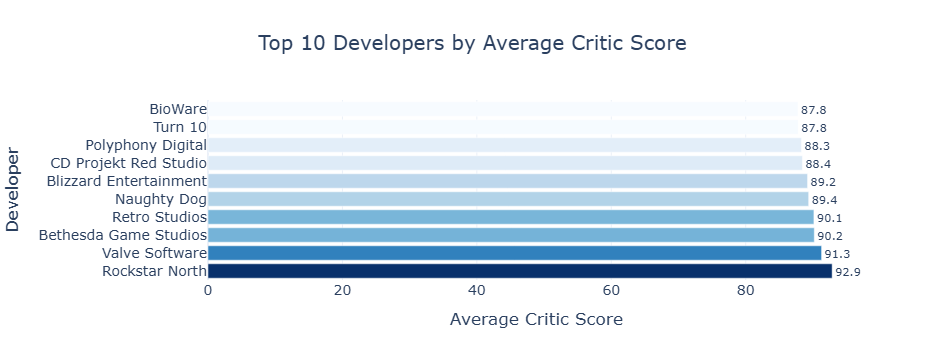

In [29]:
fig = px.bar(
    developer_scores,
    x="Average_Critic_Score",
    y="Developer",
    orientation="h",
    color="Average_Critic_Score",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Top 10 Developers by Average Critic Score"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Average Critic Score",
    yaxis_title="Developer",
    coloraxis_showscale=False,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

# Insight
    The chart highlights the developers with the highest average critic scores among those with at least five released games. These developers consistently produce high-quality titles, demonstrating sustained excellence rather than success from a single game. This suggests that development expertise and consistent quality contribute significantly to critical acclaim.

# Question 8: How do global sales vary across ESRB ratings?

In [30]:
rating_sales = (
    games_df
    .dropna(subset=["Rating"])
    .groupby("Rating", as_index=False)
    .agg(
        Average_Global_Sales=("Global_Sales", "mean"),
        Number_of_Games=("Name", "count")
    )
    .sort_values(by="Average_Global_Sales", ascending=False)
)

rating_sales

,Rating,Average_Global_Sales,Number_of_Games
0,AO,1.950000,1
3,K-A,1.920000,1
4,M,1.001296,1458
1,E,0.944170,2120
2,E10+,0.595275,946
6,T,0.590718,2411
5,RP,0.030000,1


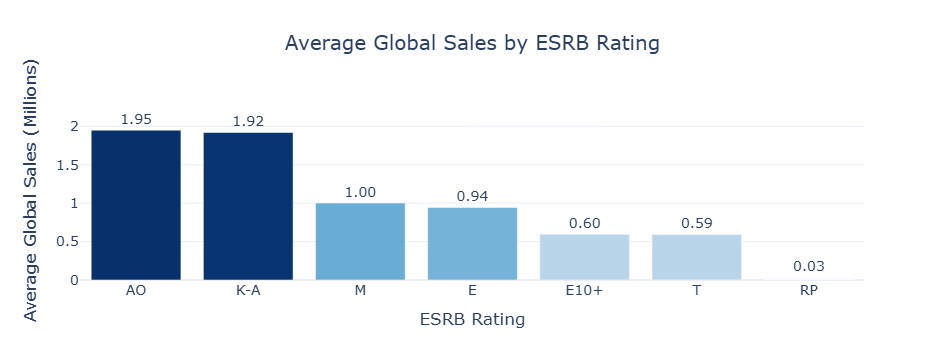

In [31]:
fig = px.bar(
    rating_sales,
    x="Rating",
    y="Average_Global_Sales",
    color="Average_Global_Sales",
    color_continuous_scale="Blues",
    text_auto=".2f",
    title="Average Global Sales by ESRB Rating"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="ESRB Rating",
    yaxis_title="Average Global Sales (Millions)",
    coloraxis_showscale=False,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

# Insight
    The chart compares the average global sales across ESRB rating categories. Games with ratings such as **E (Everyone)** and **E10+** generally achieve higher average sales, indicating their broader audience appeal. In contrast, more restrictive ratings tend to have lower average sales, reflecting a smaller target market.

# Question 9: Which genre-platform combinations generate the highest global sales?

In [32]:
genre_platform_sales = (
    games_df
    .groupby(["Platform", "Genre"])["Global_Sales"]
    .sum()
    .reset_index()
)

heatmap_data = genre_platform_sales.pivot(
    index="Platform",
    columns="Genre",
    values="Global_Sales"
).fillna(0)

heatmap_data.head()

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
3DS,32.97,2.00,2.63,4.48,27.61,2.63,13.89,18.94,1.02,16.69,2.20,0.94
DC,0.00,1.33,0.56,0.00,0.12,0.00,0.20,0.68,0.05,0.52,1.09,0.00
DS,43.04,8.83,3.37,69.48,55.02,50.50,30.54,60.92,6.40,42.71,6.01,8.00
GBA,25.05,4.54,3.29,9.20,40.36,5.47,12.60,21.61,1.40,2.65,6.53,3.34
GC,30.61,4.56,22.88,12.72,24.67,3.31,11.69,12.48,13.04,8.39,20.53,3.45


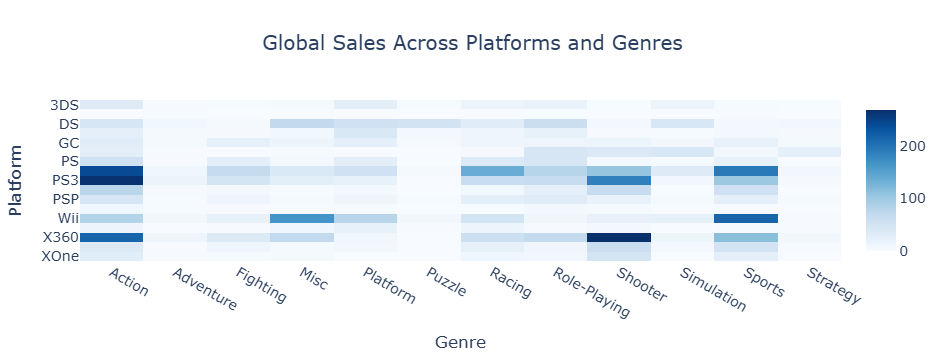

In [33]:
fig = px.imshow(
    heatmap_data,
    color_continuous_scale="Blues",
    aspect="auto",
    title="Global Sales Across Platforms and Genres"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Genre",
    yaxis_title="Platform",
    font=dict(size=14)
)

fig.show()

# Insight
    The heatmap highlights the combinations of gaming platforms and genres that have generated the highest global sales. Certain genres consistently perform well across multiple platforms, while others achieve success only on specific platforms. This indicates that both platform popularity and genre preference influence commercial performance.

# Question 10: Which decade produced the highest global video game sales?

In [34]:
decade_sales = (
    games_df
    .groupby("Decade", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Decade")
)

decade_sales

,Decade,Global_Sales
0,1980.0,0.06
1,1990.0,168.37
2,2000.0,3438.93
3,2010.0,1856.85


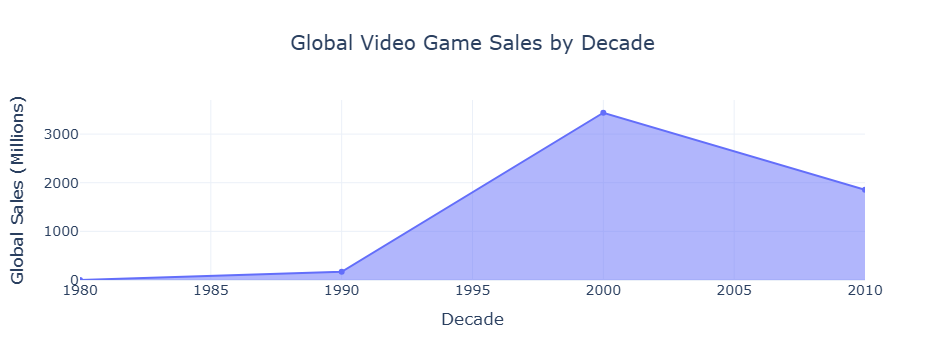

In [35]:
fig = px.area(
    decade_sales,
    x="Decade",
    y="Global_Sales",
    markers=True,
    title="Global Video Game Sales by Decade"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Decade",
    yaxis_title="Global Sales (Millions)",
    font=dict(size=14)
)

fig.show()

# Insight
    The visualization shows how global video game sales have evolved across different decades. The 2000s represent the most commercially successful period in the dataset, reflecting rapid growth in the gaming industry. Sales in subsequent decades differ due to changing market conditions and the availability of more recent release data.

# Overall Key Findings
    Based on the exploratory analysis and visualizations, the following key findings were identified:
    
    1. Nintendo platforms such as the Wii and DS generated some of the highest global video game sales.
    2. Action and Sports were the most commercially successful game genres.
    3. Global video game sales increased rapidly during the early 2000s and reached their peak before gradually declining.
    4. Games with higher critic scores generally achieved stronger commercial performance.
    5. User scores and critic scores showed a positive relationship, although some games received mixed opinions.
    6. Nintendo, Electronic Arts, and Activision were among the highest-selling publishers.
    7. Developers with consistently high critic scores demonstrated strong game development quality.
    8. ESRB ratings influenced commercial performance, with E and M rated games accounting for a large share of successful titles.
    9. Certain platform–genre combinations consistently outperformed others, highlighting the importance of platform compatibility.
    10. The 2000s represented the most commercially successful decade in the dataset.

# Conclusion
    This project analyzed a video game sales dataset to identify the factors contributing to commercial success. The analysis included data cleaning, exploratory data analysis, feature engineering, and ten analytical questions supported by interactive Plotly visualizations.
    
    The results indicate that platform popularity, genre, publisher, critic reviews, and release period all play important roles in determining game sales. Nintendo platforms and publishers dominated global sales, while Action and Sports genres consistently performed well. Additionally, critic scores showed a positive relationship with commercial success, suggesting that game quality contributes to market performance.
    
    Overall, this analysis demonstrates how interactive data visualization can uncover meaningful insights from large datasets and support data-driven decision-making within the gaming industry.